In [3]:
data(morley)
library(dplyr)
library(ggplot2)

In [4]:
morley_wide <- reshape(morley,
                       timevar = "Run",
                       idvar = "Expt",
                       direction = "wide")

In [5]:
morley_wide %>%
  rowwise() %>%
  mutate(
    media = mean(c_across(starts_with("Speed"))),
    dp    = sd(c_across(starts_with("Speed"))),
    min = min(c_across(starts_with("Speed"))),
    max    = max(c_across(starts_with("Speed")))
  ) %>%
  select(Expt, media, dp,min,max)

Expt,media,dp,min,max
<int>,<dbl>,<dbl>,<int>,<int>
1,909.0,104.92604,650,1070
2,856.0,61.16414,760,960
3,845.0,79.10686,620,970
4,820.5,60.04165,720,920
5,831.5,54.21934,740,950


In [8]:
library(dplyr)
library(nortest)
library(moments)
morley %>%
  group_by(Expt) %>%
  summarise(
    W = shapiro.test(Speed)$statistic,
    p_valor_sw = shapiro.test(Speed)$p.value,
    p_valor_ad = ad.test(Speed)$p.value,
    p_valor_ks = ks.test(Speed, "pnorm", mean(Speed), sd(Speed))$p.value,
    p_valor_cvm = bonett.test(Speed)$p.value
  )

Warning message:
"There were 5 warnings in `summarise()`.
The first warning was:
ℹ In argument: `p_valor_ks = ks.test(Speed, "pnorm", mean(Speed),
  sd(Speed))$p.value`.
ℹ In group 1: `Expt = 1`.
Caused by warning in `ks.test.default()`:
! ties should not be present for the Kolmogorov-Smirnov test
ℹ Run `dplyr::last_dplyr_warnings()` to see the 4 remaining warnings."


Expt,W,p_valor_sw,p_valor_ad,p_valor_ks,p_valor_cvm
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.9199248,0.098755612,0.0670995838,0.54102128,0.7330141497
2,0.9317972,0.167208431,0.1837626771,0.91819384,0.1520508886
3,0.8368485,0.003234519,0.0005913858,0.02940198,0.0002601784
4,0.9611299,0.566662969,0.6584714199,0.98824331,0.1625726339
5,0.9351800,0.194142597,0.0970743988,0.37508160,0.7932956549


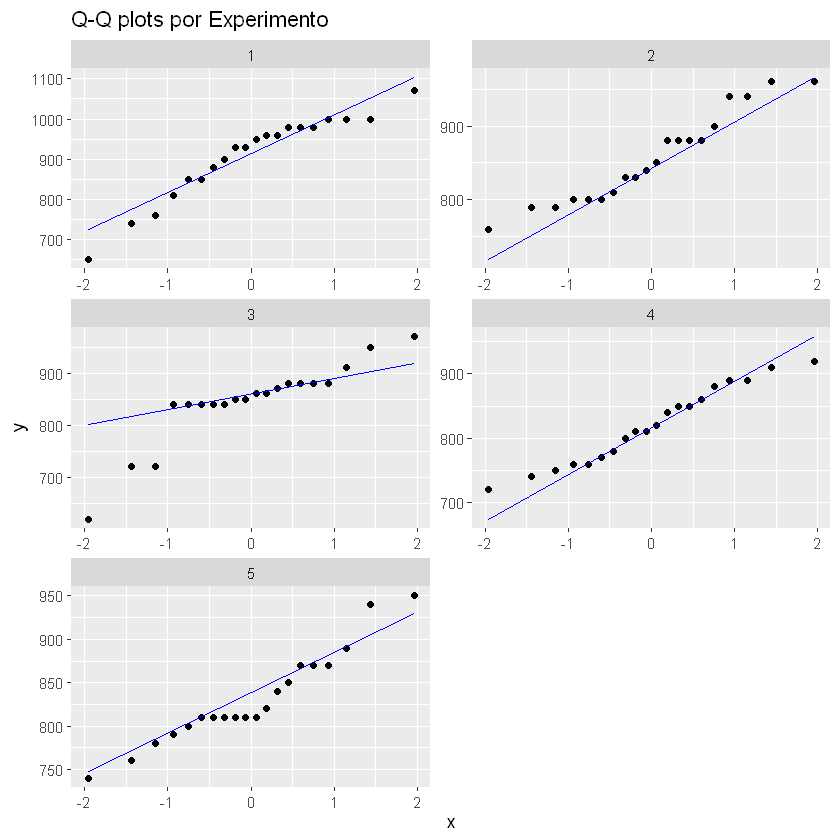

In [ ]:
library(ggplot2)

ggplot(morley, aes(sample = Speed)) +
  stat_qq() +
  stat_qq_line(col = "blue") +
  facet_wrap(~ Expt, scales = "free", ncol = 2) +
  labs(title = "Q-Q plots por Experimento")

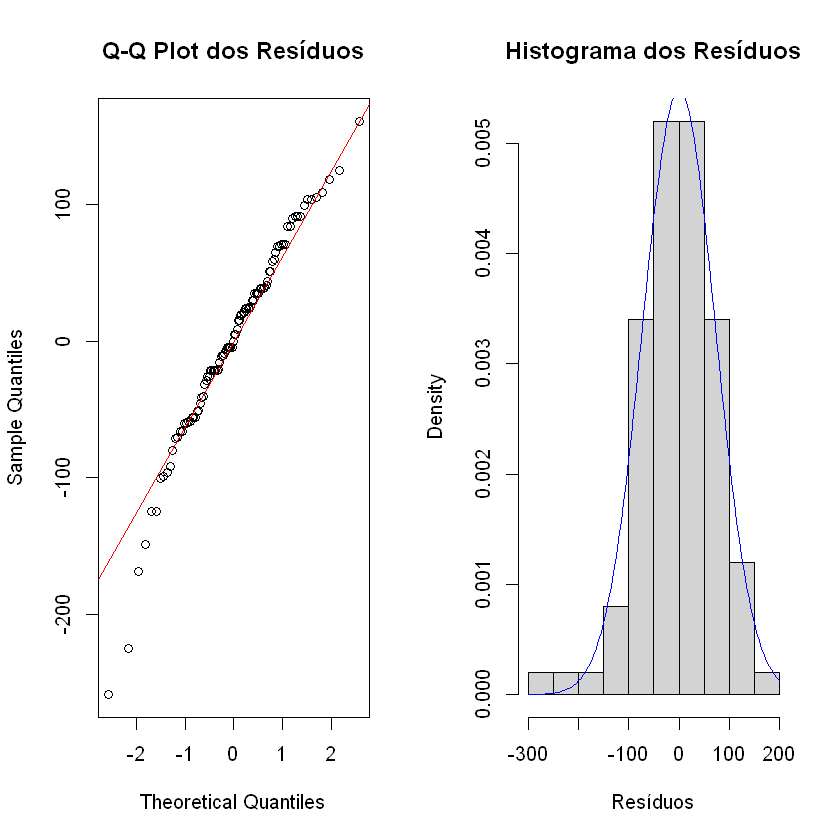

In [ ]:
# a) Q-Q plot dos resíduos
par(mfrow = c(1,2))
qqnorm(residuals(modelo), main = "Q-Q Plot dos Resíduos")
qqline(residuals(modelo), col = "red")

# b) Histograma com curva normal teórica
hist(residuals(modelo), breaks = 10, probability = TRUE, 
     main = "Histograma dos Resíduos", xlab = "Resíduos")
curve(dnorm(x, mean = mean(residuals(modelo)), sd = sd(residuals(modelo))), 
      add = TRUE, col = "blue")

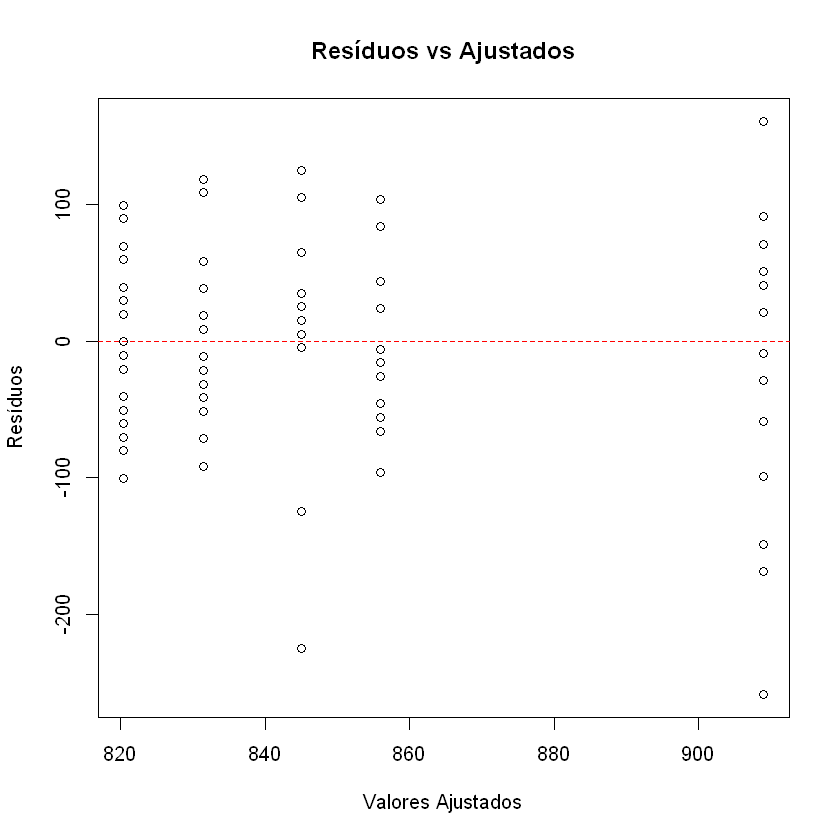

In [ ]:
modelo <- aov(Speed ~ Expt, data = morley)
plot(fitted(modelo), residuals(modelo), 
     xlab = "Valores Ajustados", ylab = "Resíduos",
     main = "Resíduos vs Ajustados")
abline(h = 0, col = "red", lty = 2)

In [ ]:
fligner.test(Speed ~ Expt, data = morley)



	Bartlett test of homogeneity of variances

data:  Speed by Expt
Bartlett's K-squared = 11.552, df = 4, p-value = 0.02102



	Fligner-Killeen test of homogeneity of variances

data:  Speed by Expt
Fligner-Killeen:med chi-squared = 5.7924, df = 4, p-value = 0.2152


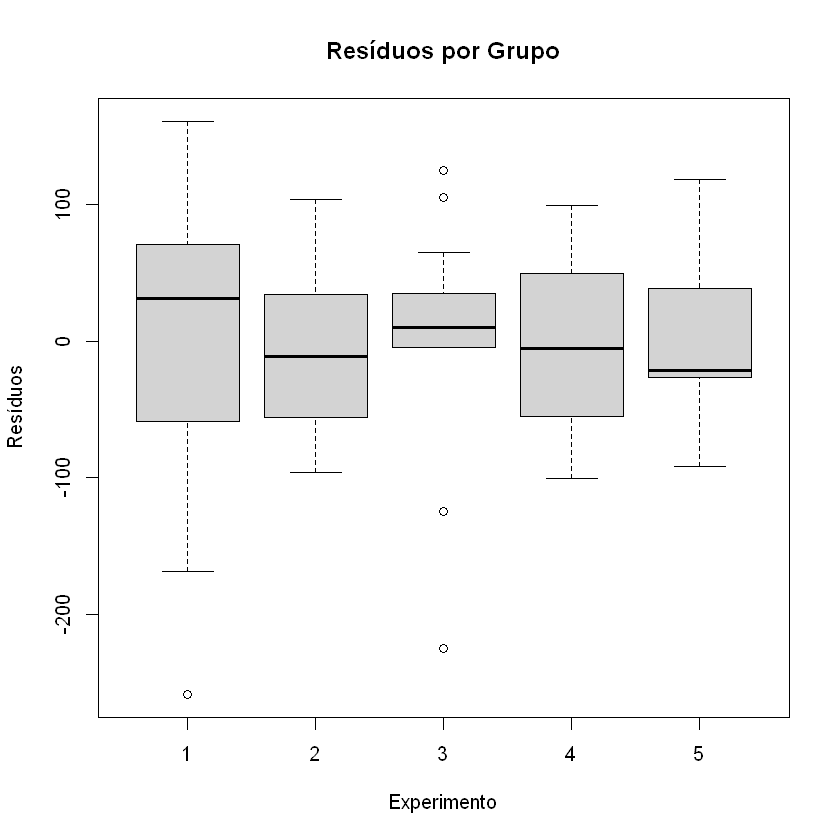

In [18]:
# b) Boxplot dos resíduos por grupo (Expt)
boxplot(residuals(modelo) ~ Expt, data = morley,
        xlab = "Experimento", ylab = "Resíduos",
        main = "Resíduos por Grupo")

In [2]:
morley$Expt <- as.factor(morley$Expt)

model_morley <- aov(Speed ~ Expt, data = morley)
summary(model_morley)

            Df Sum Sq Mean Sq F value  Pr(>F)   
Expt         4  94514   23629   4.288 0.00311 **
Residuals   95 523510    5511                   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

In [11]:
data(morley)
morley$Expt <- as.factor(morley$Expt)

# Usando t.test para cada grupo (IC 95% individual)
ic_individual <- by(morley$Speed, morley$Expt, function(x) t.test(x)$conf.int)
ic_individual

# Ou formatando em tabela:
library(dplyr)
ic_tabela <- morley %>%
  group_by(Expt) %>%
  summarise(
    media = mean(Speed),
    sd = sd(Speed),
    n = n(),
    ic_inf = media - qt(0.975, n-1) * sd/sqrt(n),
    ic_sup = media + qt(0.975, n-1) * sd/sqrt(n)
  )
print(ic_tabela)

morley$Expt: 1
[1] 859.8931 958.1069
attr(,"conf.level")
[1] 0.95
------------------------------------------------------------ 
morley$Expt: 2
[1] 827.3743 884.6257
attr(,"conf.level")
[1] 0.95
------------------------------------------------------------ 
morley$Expt: 3
[1] 807.9769 882.0231
attr(,"conf.level")
[1] 0.95
------------------------------------------------------------ 
morley$Expt: 4
[1] 792.3996 848.6004
attr(,"conf.level")
[1] 0.95
------------------------------------------------------------ 
morley$Expt: 5
[1] 806.1246 856.8754
attr(,"conf.level")
[1] 0.95

# A tibble: 5 × 6
  Expt  media    sd     n ic_inf ic_sup
  <fct> <dbl> <dbl> <int>  <dbl>  <dbl>
1 1      909  105.     20   860.   958.
2 2      856   61.2    20   827.   885.
3 3      845   79.1    20   808.   882.
4 4      820.  60.0    20   792.   849.
5 5      832.  54.2    20   806.   857.


In [12]:
# Ajustar o modelo ANOVA
modelo <- aov(Speed ~ Expt, data = morley)
summary(modelo)

# Obter o MSE e os gl do resíduo
mse <- summary(modelo)[[1]]$"Mean Sq"[2]
gl_res <- df.residual(modelo)

# Número de comparações (pares)
k <- nlevels(morley$Expt)          # 5 grupos
m <- k * (k-1) / 2                  # 10 comparações

# Valor crítico de t ajustado por Bonferroni
alpha <- 0.05
t_crit <- qt(1 - alpha/(2*m), gl_res)

# Calcular todas as diferenças e seus ICs
medias <- tapply(morley$Speed, morley$Expt, mean)
n_grupos <- tapply(morley$Speed, morley$Expt, length)

# Matriz de resultados
pares <- combn(levels(morley$Expt), 2)
resultados <- data.frame(
  Comparacao = apply(pares, 2, paste, collapse = " - "),
  Diferenca = apply(pares, 2, function(par) medias[par[1]] - medias[par[2]]),
  IC_inf = NA,
  IC_sup = NA
)

for (i in 1:ncol(pares)) {
  dif <- resultados$Diferenca[i]
  erro_padrao <- sqrt(mse * (1/n_grupos[pares[1,i]] + 1/n_grupos[pares[2,i]]))
  resultados$IC_inf[i] <- dif - t_crit * erro_padrao
  resultados$IC_sup[i] <- dif + t_crit * erro_padrao
}

print(resultados)

            Df Sum Sq Mean Sq F value  Pr(>F)   
Expt         4  94514   23629   4.288 0.00311 **
Residuals   95 523510    5511                   
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

   Comparacao Diferenca     IC_inf    IC_sup
1       1 - 2      53.0 -14.468109 120.46811
2       1 - 3      64.0  -3.468109 131.46811
3       1 - 4      88.5  21.031891 155.96811
4       1 - 5      77.5  10.031891 144.96811
5       2 - 3      11.0 -56.468109  78.46811
6       2 - 4      35.5 -31.968109 102.96811
7       2 - 5      24.5 -42.968109  91.96811
8       3 - 4      24.5 -42.968109  91.96811
9       3 - 5      13.5 -53.968109  80.96811
10      4 - 5     -11.0 -78.468109  56.46811


In [13]:
library(knitr)
tabela <- data.frame(
  Experimento = 1:5,
  Média = c(909, 856, 845, 820, 832),
  `Desvio Padrão` = c(104.7, 61.2, 79.1, 60.0, 54.2),
  n = 20,
  `IC 95% inferior` = c(860, 827, 808, 792, 806),
  `IC 95% superior` = c(958, 885, 882, 849, 857)
)
kable(tabela, format = "latex", booktabs = TRUE, digits = 1)


\begin{tabular}{rrrrrr}
\toprule
Experimento & Média & Desvio.Padrão & n & IC.95..inferior & IC.95..superior\\
\midrule
1 & 909 & 104.7 & 20 & 860 & 958\\
2 & 856 & 61.2 & 20 & 827 & 885\\
3 & 845 & 79.1 & 20 & 808 & 882\\
4 & 820 & 60.0 & 20 & 792 & 849\\
5 & 832 & 54.2 & 20 & 806 & 857\\
\bottomrule
\end{tabular}

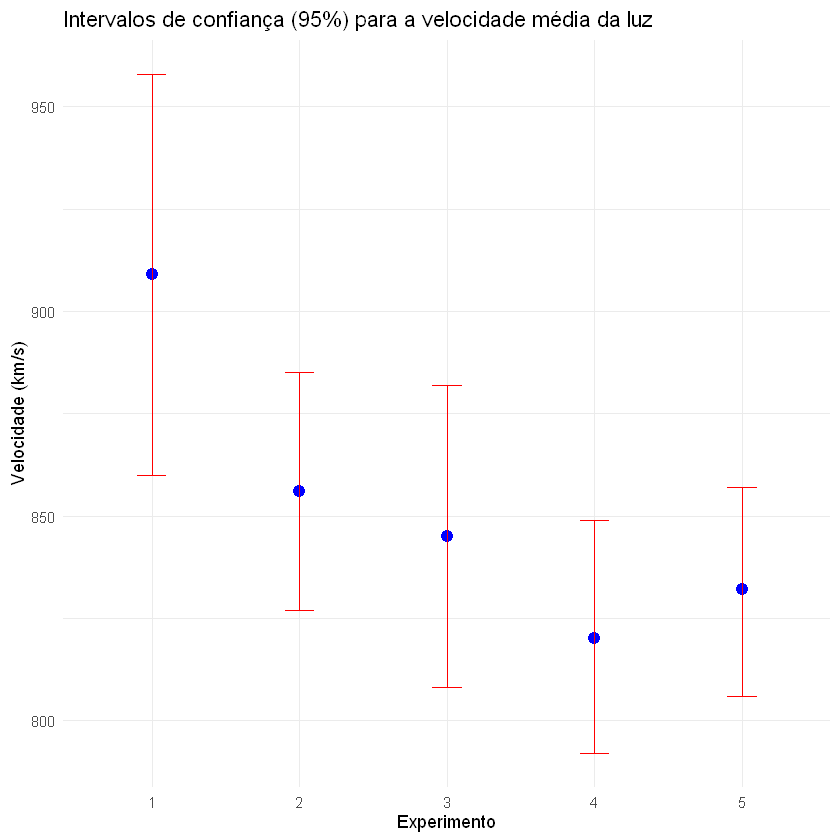

In [14]:
library(ggplot2)

# Seus dados (já calculados)
dados_ic <- data.frame(
  Expt = factor(1:5),
  media = c(909, 856, 845, 820, 832),
  ic_inf = c(860, 827, 808, 792, 806),
  ic_sup = c(958, 885, 882, 849, 857)
)

ggplot(dados_ic, aes(x = Expt, y = media)) +
  geom_point(size = 3, color = "blue") +
  geom_errorbar(aes(ymin = ic_inf, ymax = ic_sup), width = 0.2, color = "red") +
  labs(title = "Intervalos de confiança (95%) para a velocidade média da luz",
       x = "Experimento", y = "Velocidade (km/s)") +
  theme_minimal()

Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'



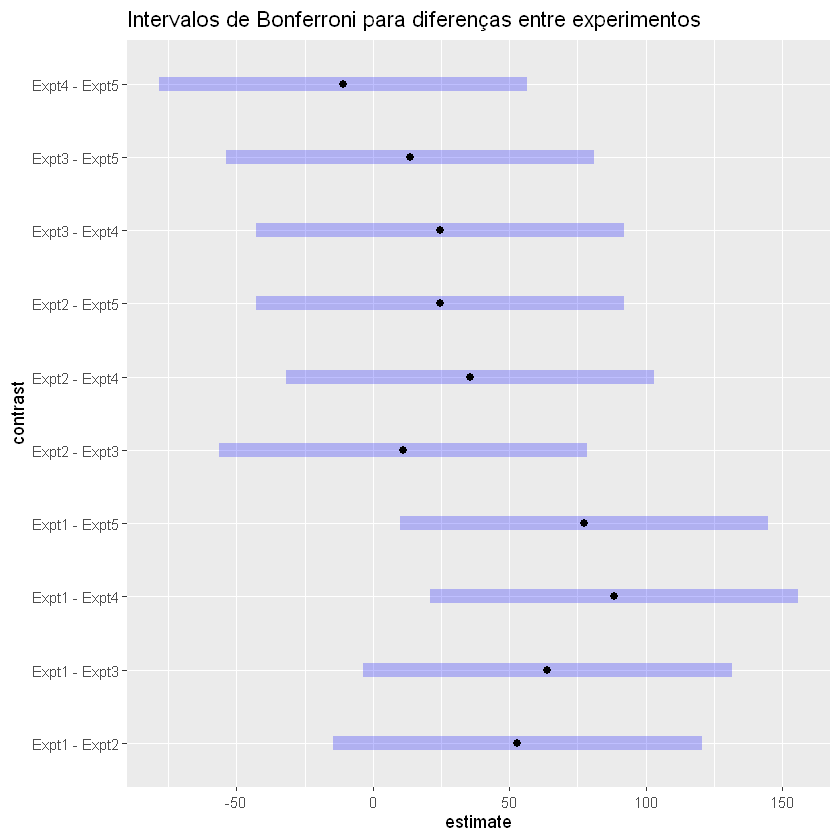

In [15]:
library(emmeans)
modelo <- aov(Speed ~ Expt, data = morley)
emm <- emmeans(modelo, "Expt")
pares_bonf <- pairs(emm, adjust = "bonferroni")
plot(pares_bonf) + 
  labs(title = "Intervalos de Bonferroni para diferenças entre experimentos")